# RetailPulse – AI-Powered Customer Analytics & Demand Forecasting Platform

## Module 1: Data Understanding & Initial EDA

### Objectives
- Understand Rossmann Store Sales dataset
- Understand Online Retail II dataset
- Identify missing values
- Assess data quality
- Prepare for feature engineering

### Author
Junaid

### Date
June 2026

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
train = pd.read_csv("../data/raw/rossmann/train.csv")
store = pd.read_csv("../data/raw/rossmann/store.csv")

print("Train Shape:", train.shape)
print("Store Shape:", store.shape)

Train Shape: (1017209, 9)
Store Shape: (1115, 10)


C:\Users\MikeY\AppData\Local\Temp\ipykernel_25780\777515754.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/rossmann/train.csv")


In [3]:
rossmann = train.merge(
    store,
    on="Store",
    how="left"
)

print("Rossmann Shape:", rossmann.shape)
rossmann.head()

Rossmann Shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
xls = pd.ExcelFile(
    "../data/raw/online_retail/online_retail_II.xlsx"
)

print("Available Sheets:")
print(xls.sheet_names)

Available Sheets:
['Year 2009-2010', 'Year 2010-2011']


In [5]:
retail_2009 = pd.read_excel(
    "../data/raw/online_retail/online_retail_II.xlsx",
    sheet_name=0
)

retail_2010 = pd.read_excel(
    "../data/raw/online_retail/online_retail_II.xlsx",
    sheet_name=1
)

retail = pd.concat(
    [retail_2009, retail_2010],
    ignore_index=True
)

print("Retail Shape:", retail.shape)

retail.head()

Retail Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print("\nROSSMANN DATASET")
rossmann.info()

print("\nONLINE RETAIL DATASET")
retail.info()


ROSSMANN DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  Compe

In [7]:
print("Train Shape:", train.shape)
print("Store Shape:", store.shape)
print("Rossmann Shape:", rossmann.shape)
print("Retail Shape:", retail.shape)

Train Shape: (1017209, 9)
Store Shape: (1115, 10)
Rossmann Shape: (1017209, 18)
Retail Shape: (1067371, 8)


In [8]:
print("\nRossmann Columns")
print(rossmann.columns.tolist())

print("\nRetail Columns")
print(retail.columns.tolist())


Rossmann Columns
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Retail Columns
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [9]:
rossmann.describe(include="all")

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1017209,1017209,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000,509178
unique,NaN,NaN,942,NaN,NaN,NaN,NaN,5,NaN,4,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,2015-07-31,NaN,NaN,NaN,NaN,0,NaN,a,a,NaN,NaN,NaN,NaN,NaN,NaN,"Jan,Apr,Jul,Oct"
freq,NaN,NaN,1115,NaN,NaN,NaN,NaN,855087,NaN,551627,537445,NaN,NaN,NaN,NaN,NaN,NaN,293122
mean,5.584297e+02,3.998341e+00,NaN,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,NaN,1.786467e-01,NaN,NaN,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774,NaN
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,NaN,3.830564e-01,NaN,NaN,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870,NaN
min,1.000000e+00,1.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00,NaN,NaN,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000,NaN
25%,2.800000e+02,2.000000e+00,NaN,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,NaN,0.000000e+00,NaN,NaN,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000,NaN
50%,5.580000e+02,4.000000e+00,NaN,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,NaN,0.000000e+00,NaN,NaN,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000,NaN
75%,8.380000e+02,6.000000e+00,NaN,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,NaN,0.000000e+00,NaN,NaN,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000,NaN


In [10]:
retail.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [11]:
print("Rossmann Duplicates:", rossmann.duplicated().sum())

print("Retail Duplicates:", retail.duplicated().sum())

Rossmann Duplicates: 0
Retail Duplicates: 34335


In [12]:
missing_rossmann = (
    rossmann.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_rossmann

Promo2SinceWeek              508031
PromoInterval                508031
Promo2SinceYear              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Store                             0
Date                              0
Sales                             0
StoreType                         0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Assortment                        0
Promo2                            0
dtype: int64

In [13]:
missing_retail = (
    retail.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_retail

Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

In [14]:
missing_percent = (
    rossmann.isnull()
    .sum()
    / len(rossmann)
    * 100
).sort_values(ascending=False)

missing_percent[missing_percent > 0]

Promo2SinceWeek              49.943620
PromoInterval                49.943620
Promo2SinceYear              49.943620
CompetitionOpenSinceYear     31.787764
CompetitionOpenSinceMonth    31.787764
CompetitionDistance           0.259730
dtype: float64

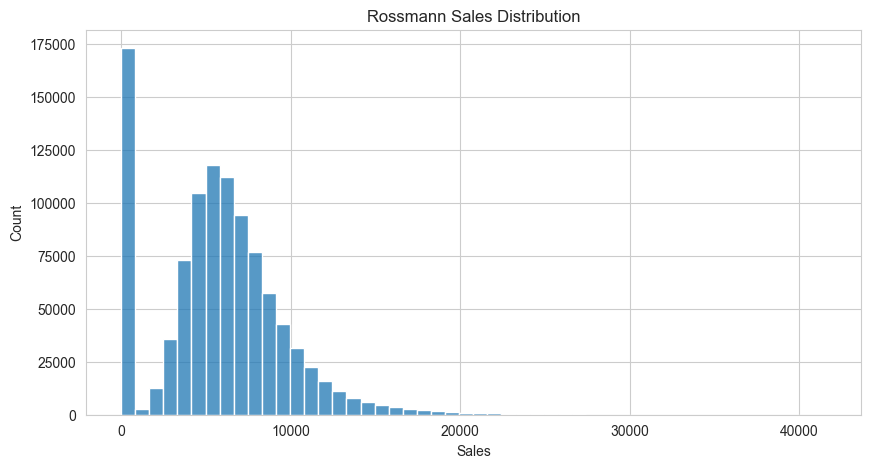

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    rossmann["Sales"],
    bins=50
)

plt.title("Rossmann Sales Distribution")
plt.show()

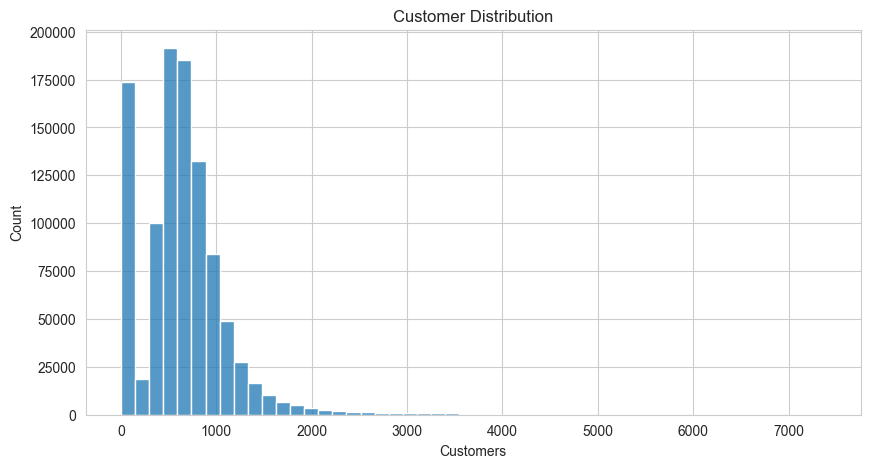

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    rossmann["Customers"],
    bins=50
)

plt.title("Customer Distribution")
plt.show()

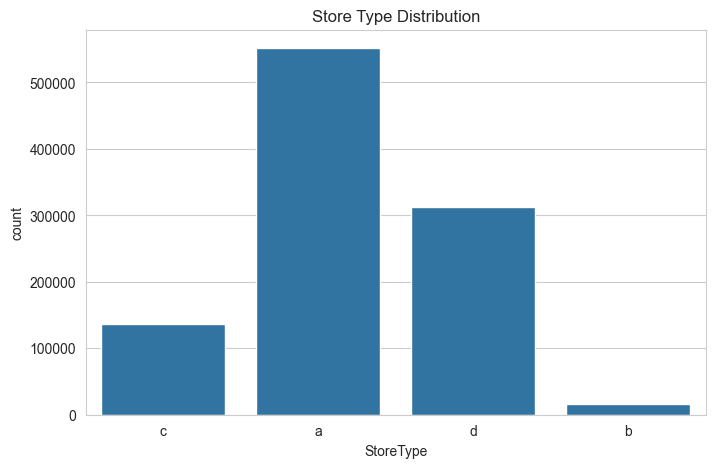

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rossmann,
    x="StoreType"
)

plt.title("Store Type Distribution")
plt.show()

In [18]:
retail["Revenue"] = (
    retail["Quantity"] *
    retail["Price"]
)

retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [19]:
country_sales = (
    retail.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: Revenue, dtype: float64

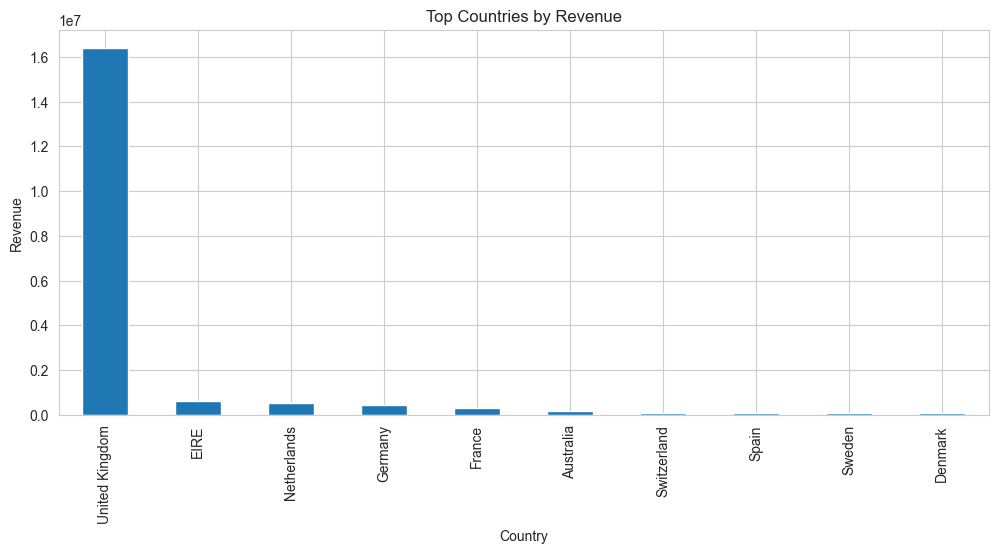

In [20]:
plt.figure(figsize=(12,5))

country_sales.plot(kind="bar")

plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")

plt.show()

# Initial Findings

## Rossmann Dataset

- Contains daily store sales information.
- Suitable for demand forecasting.
- Missing values exist in competition-related features.
- Sales and customer counts show significant variability.

## Online Retail Dataset

- Contains transactional customer purchase records.
- Suitable for customer analytics and segmentation.
- Missing Customer IDs require investigation.
- Revenue feature successfully created.

## Next Steps

- Data Cleaning
- Missing Value Treatment
- Feature Engineering
- Customer Segmentation
- Demand Forecasting

# Rossmann Dataset Overview

| Column | Description |
|----------|------------|
| Store | Store ID |
| DayOfWeek | Day of Week |
| Date | Sales Date |
| Sales | Daily Sales Revenue |
| Customers | Daily Customer Count |
| Open | Store Open Indicator |
| Promo | Promotion Indicator |
| StateHoliday | State Holiday Indicator |
| SchoolHoliday | School Holiday Indicator |
| StoreType | Store Category |
| Assortment | Product Assortment Level |
| CompetitionDistance | Distance to Nearest Competitor |

# Online Retail II Dataset Overview

| Column | Description |
|----------|------------|
| Invoice | Invoice Number |
| StockCode | Product Code |
| Description | Product Description |
| Quantity | Quantity Purchased |
| InvoiceDate | Transaction Timestamp |
| Price | Unit Price |
| Customer ID | Customer Identifier |
| Country | Customer Country |

In [21]:
rossmann.isnull().sum().sort_values(ascending=False)

Promo2SinceWeek              508031
PromoInterval                508031
Promo2SinceYear              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Store                             0
Date                              0
Sales                             0
StoreType                         0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Assortment                        0
Promo2                            0
dtype: int64

In [22]:
retail.isnull().sum().sort_values(ascending=False)

Customer ID    243007
Description      4382
Invoice             0
Quantity            0
StockCode           0
InvoiceDate         0
Price               0
Country             0
Revenue             0
dtype: int64